[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/camiloandcu/Retail-Demand-Forecasting/blob/main/03_non_neural_baselines.ipynb)

# 03 - Non-neural baselines

This notebook evaluates four pre-registered configurations on the same rolling-origin folds: zero, weekly seasonal naive, a four-week seasonal average, and one global LightGBM model. It writes `artifacts/metrics/baseline_results.csv`, OOF predictions, figures, a champion contract, and local MLflow runs. No recurrent model is trained.

In [1]:
import importlib.util
import os
import shutil
import subprocess
import sys
from getpass import getpass
from pathlib import Path

REPO_URL = "https://github.com/camiloandcu/Retail-Demand-Forecasting.git"
BRANCH = "feat-baselines-and-academic-document"  # Change to "main" before merging.
IN_COLAB = importlib.util.find_spec("google.colab") is not None
if IN_COLAB:
    REPO_ROOT = Path("/content/Retail-Demand-Forecasting")
    if not (REPO_ROOT / "pyproject.toml").is_file():
        subprocess.run(
            [
                "git",
                "clone",
                "--branch",
                BRANCH,
                "--single-branch",
                "--depth",
                "1",
                REPO_URL,
                str(REPO_ROOT),
            ],
            check=True,
        )
    else:
        subprocess.run(
            ["git", "-C", str(REPO_ROOT), "fetch", "--depth", "1", "origin", BRANCH],
            check=True,
        )
        subprocess.run(
            ["git", "-C", str(REPO_ROOT), "checkout", "--detach", "FETCH_HEAD"],
            check=True,
        )
else:
    REPO_ROOT = Path.cwd().resolve()
    if not (REPO_ROOT / "pyproject.toml").is_file():
        raise RuntimeError("Run the notebook from the repository root.")
os.chdir(REPO_ROOT)
if importlib.util.find_spec("pip") is not None:
    install_command = [sys.executable, "-m", "pip", "install", "-e", ".[notebook,dev,models]"]
elif shutil.which("uv"):
    install_command = [
        "uv",
        "pip",
        "install",
        "--python",
        sys.executable,
        "-e",
        ".[notebook,dev,models]",
    ]
else:
    raise RuntimeError("This environment provides neither pip nor uv.")
subprocess.run(install_command, check=True)
source_path = str(REPO_ROOT / "src")
if source_path not in sys.path:
    sys.path.insert(0, source_path)
print(f"Repository ready at {REPO_ROOT} with Python {sys.version.split()[0]}")

Repository ready at /content/Retail-Demand-Forecasting with Python 3.13.15


In [2]:
import pandas as pd
from IPython.display import Image, display

from retail_forecast.acquisition import acquire_competition_data
from retail_forecast.config import load_config
from retail_forecast.data import (
    load_frames,
    required_files_exist,
    validate_dataset,
    write_synthetic_dataset,
)
from retail_forecast.eda import validate_kaggle_hashes
from retail_forecast.experiments import MODEL_IDS, run_baseline_experiments
from retail_forecast.reproducibility import set_global_seed

MODE = os.getenv("RETAIL_FORECAST_MODE", "full").strip().lower()
if MODE not in {"full", "smoke"}:
    raise ValueError("RETAIL_FORECAST_MODE must be 'full' or 'smoke'.")
config = load_config(f"configs/{MODE}.yaml")
set_global_seed(config.runtime.seed)
print(f"mode={MODE} | configurations={len(MODEL_IDS)} | tree={config.baseline.tree_model}")

mode=full | configurations=4 | tree=lightgbm


## Data

Existing CSVs and a locally available competition ZIP are reused automatically. If neither is present, the next cell asks for a Kaggle API token using hidden input.

In [3]:
if config.data.source == "synthetic":
    if not required_files_exist(config.paths.raw_data_dir):
        write_synthetic_dataset(config)
elif not required_files_exist(config.paths.raw_data_dir):
    acquire_competition_data(
        config.paths.raw_data_dir,
        (REPO_ROOT / "data", REPO_ROOT),
        token_reader=getpass,
    )
if MODE == "full":
    validate_kaggle_hashes(config.paths.raw_data_dir)
dataset_summary = validate_dataset(config)
frames = load_frames(config.paths.raw_data_dir)
display(dataset_summary.to_dict())

Kaggle API token (press Enter to continue without one): ··········


100%|██████████| 21.4M/21.4M [00:00<00:00, 67.9MB/s]

Extracting files...


{'train_rows': 3000888,
 'test_rows': 28512,
 'stores': 54,
 'families': 33,
 'series': 1782,
 'train_start': '2013-01-01',
 'train_end': '2017-08-15',
 'test_start': '2017-08-16',
 'test_end': '2017-08-31',
 'horizon': 16,
 'source': 'kaggle'}

## Decisions fixed before training

LightGBM is the only tree model. The training code declares the six encoded categorical columns directly, learns `log1p(sales)`, and clips negative predictions to zero before RMSLE.

The experiment budget is four configurations. A recurrent model will only qualify if its global OOF RMSLE is at least 2% below LightGBM on these same folds. Smoke results validate code only and cannot select a champion.

In [4]:
run = run_baseline_experiments(
    config,
    frames,
    REPO_ROOT / "artifacts/metrics",
    REPO_ROOT / "artifacts/figures/baselines",
    REPO_ROOT / "mlruns",
)

2026/09/17 03:25:12 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/09/17 03:25:12 INFO mlflow.store.db.utils: Updating database tables
2026/09/17 03:25:15 INFO mlflow.tracking.fluent: Experiment with name 'retail-demand-non-neural-baselines' does not exist. Creating a new experiment.


## Quality and cost

The tables compare global RMSLE, each validation fold, and each forecast day. The figures below show the global and horizon comparisons. Store, family, promotion, and calendar-regime scores remain in `baseline_results.csv`.

,model_id,duration_seconds,process_max_rss_kib,max_training_rows,rmsle
0,lightgbm_global,122.856639,2482268,655776,0.397316
1,seasonal_average_4w,4.902499,2394064,0,0.468430
2,seasonal_naive_7d,5.674772,2378364,0,0.553861
3,zero,0.000134,2378364,0,4.419661


model_id        lightgbm_global  seasonal_average_4w  seasonal_naive_7d  \
scope  segment                                                            
fold   fold_1          0.378241             0.424515           0.517619   
       fold_2          0.398060             0.442683           0.521169   
       fold_3          0.414803             0.531130           0.617040   
global all             0.397316             0.468430           0.553861   

model_id            zero  
scope  segment            
fold   fold_1   4.420194  
       fold_2   4.419289  
       fold_3   4.419500  
global all      4.419661

model_id,lightgbm_global,seasonal_average_4w,seasonal_naive_7d,zero
segment,,,,
1,0.377535,0.443373,0.530317,4.403492
2,0.374788,0.451406,0.544037,4.504660
3,0.371660,0.456059,0.553400,4.526563
4,0.383907,0.453989,0.542172,4.449900
5,0.392036,0.463559,0.547985,4.398002
6,0.388676,0.445117,0.536762,4.416225
7,0.395255,0.440836,0.525892,4.444716
8,0.394789,0.475479,0.553847,4.404729
9,0.399338,0.473245,0.556510,4.422195


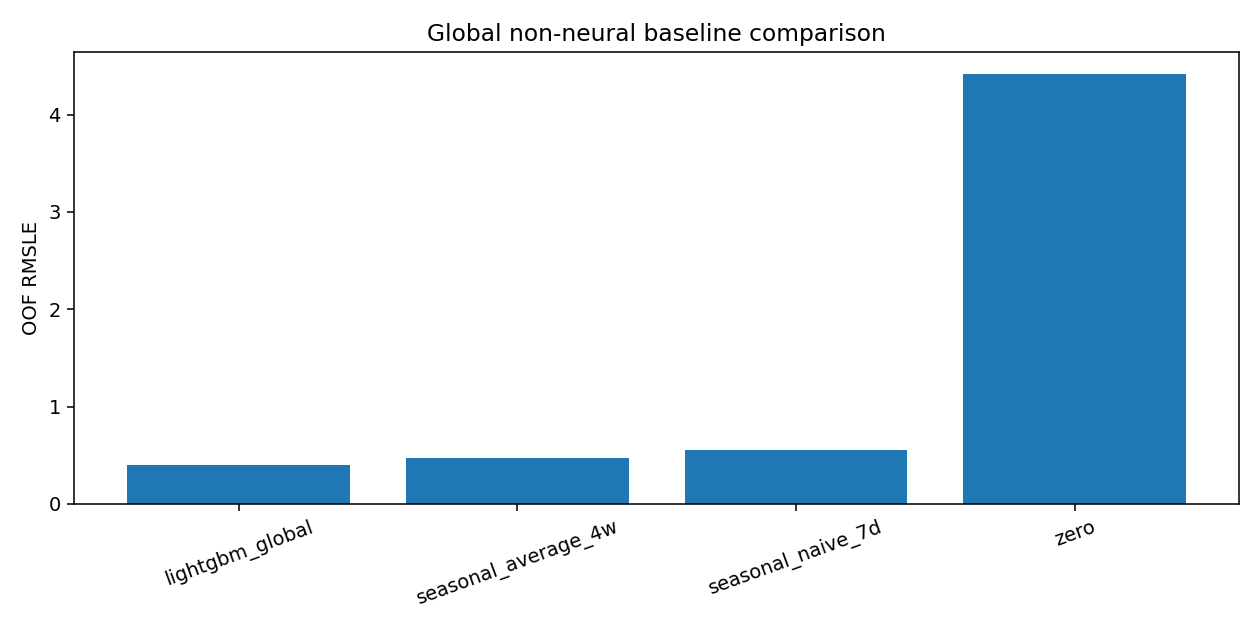

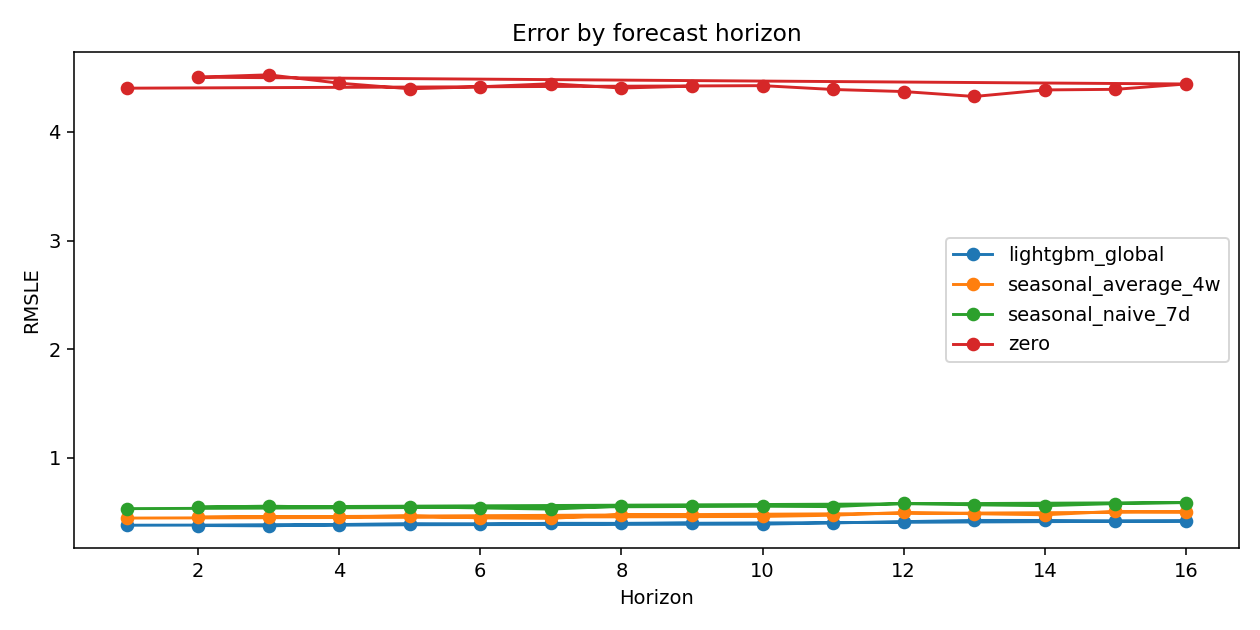

In [5]:
display(run["cost_quality"])
display(
    run["results"]
    .loc[run["results"]["scope"].isin(["global", "fold"])]
    .pivot_table(index=["scope", "segment"], columns="model_id", values="rmsle")
)
display(
    run["results"]
    .loc[run["results"]["scope"].eq("horizon")]
    .assign(segment=lambda frame: frame["segment"].astype(int))
    .pivot(index="segment", columns="model_id", values="rmsle")
)
display(Image(filename=str(REPO_ROOT / "artifacts/figures/baselines/01_global_rmsle.png")))
display(Image(filename=str(REPO_ROOT / "artifacts/figures/baselines/02_horizon_rmsle.png")))

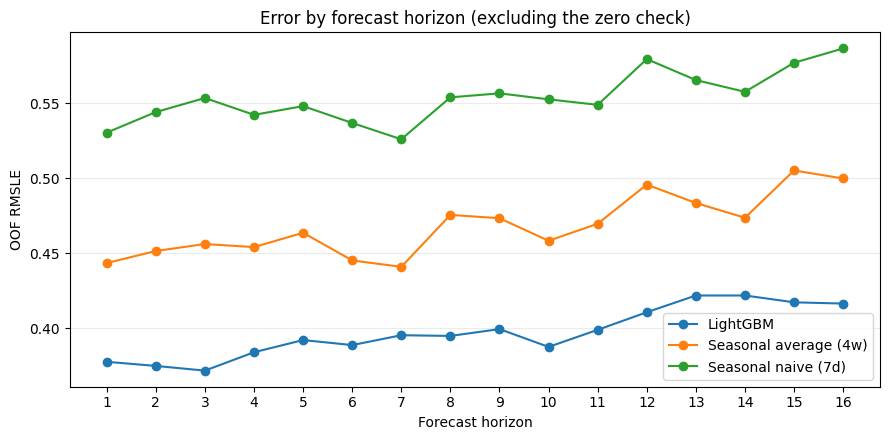

Saved: /content/Retail-Demand-Forecasting/artifacts/figures/baselines/02_horizon_rmsle_without_zero.png


In [6]:
import matplotlib.pyplot as plt

horizon_without_zero = (
    run["results"]
    .loc[run["results"]["scope"].eq("horizon") & run["results"]["model_id"].ne("zero")]
    .assign(segment=lambda frame: frame["segment"].astype(int))
    .sort_values(["model_id", "segment"])
)

labels = {
    "seasonal_naive_7d": "Seasonal naive (7d)",
    "seasonal_average_4w": "Seasonal average (4w)",
    "lightgbm_global": "LightGBM",
}
figure, axis = plt.subplots(figsize=(9, 4.5))
for model_id, model_frame in horizon_without_zero.groupby("model_id", sort=False):
    axis.plot(
        model_frame["segment"],
        model_frame["rmsle"],
        marker="o",
        label=labels[model_id],
    )
axis.set(
    xlabel="Forecast horizon",
    ylabel="OOF RMSLE",
    title="Error by forecast horizon (excluding the zero check)",
)
axis.set_xticks(sorted(horizon_without_zero["segment"].unique()))
axis.grid(axis="y", alpha=0.25)
axis.legend()
figure.tight_layout()

figure_path = REPO_ROOT / "artifacts/figures/baselines/02_horizon_rmsle_without_zero.png"
figure_path.parent.mkdir(parents=True, exist_ok=True)
figure.savefig(figure_path, dpi=140, bbox_inches="tight")
plt.show()
print(f"Saved: {figure_path}")

## Reading the comparison

The zero check towers above the other methods and stretches the figures' scale. Use the table to compare the useful models: LightGBM leads, while the four-week average is the strongest simple baseline. We now have both a demanding ML reference and an understandable comparator.

Every useful method is less accurate in the last fold. A good global score can hide a weak period, so the next model must be checked fold by fold. This table does not explain what caused the change.

LightGBM leads across the forecast days, but its error varies rather than rising smoothly. Lead days also fall on different calendar dates, so the curve alone cannot explain the variation. Keep the same folds and compare every forecast day in the next experiment.

This describes the saved run. Smoke plots are synthetic and do not measure forecasting quality.

## What the next model must beat

The four-week average is the transparent business baseline; LightGBM is the ML model to beat. The champion artifact below records the pre-set acceptance threshold. Judge a recurrent model on the same folds, then check its errors by fold and forecast day so an overall win does not hide a weak stretch.

In [7]:
display(run["champion"])
display(run["manifest"])
for name, path in run["paths"].items():
    print(f"{name}: {path}")

{'mode': 'full',
 'empirical_results_are_synthetic': False,
 'business_baseline': 'seasonal_average_4w',
 'business_baseline_rmsle': 0.468430329276968,
 'non_neural_reference': 'lightgbm_global',
 'non_neural_reference_rmsle': 0.397315983234047,
 'neural_min_relative_improvement': 0.02,
 'neural_rmsle_threshold': 0.38936966356936603,
 'configuration_count': 4,
 'tree_parameters': {'objective': 'regression',
  'n_estimators': 300,
  'learning_rate': 0.05,
  'num_leaves': 31,
  'min_child_samples': 100,
  'colsample_bytree': 0.8,
  'reg_lambda': 1.0,
  'random_state': 2026,
  'n_jobs': -1,
  'deterministic': True,
  'force_col_wise': True,
  'verbosity': -1},
 'limitations_for_recurrent_model': ['Origin-level summaries do not preserve the full order of the 56-day history.',
  'One pooled tree objective may underrepresent intermittent, high-zero series.',
  'Separate horizon rows cannot learn a joint 16-step sequence representation.']}

{'mode': 'full',
 'source': 'kaggle',
 'models': ['zero',
  'seasonal_naive_7d',
  'seasonal_average_4w',
  'lightgbm_global'],
 'tree_selected_before_training': 'lightgbm',
 'folds': [{'name': 'fold_1',
   'origin': '2017-06-28',
   'train_start': '2013-01-01',
   'train_end': '2017-06-28',
   'validation_start': '2017-06-29',
   'validation_end': '2017-07-14',
   'horizon': 16},
  {'name': 'fold_2',
   'origin': '2017-07-14',
   'train_start': '2013-01-01',
   'train_end': '2017-07-14',
   'validation_start': '2017-07-15',
   'validation_end': '2017-07-30',
   'horizon': 16},
  {'name': 'fold_3',
   'origin': '2017-07-30',
   'train_start': '2013-01-01',
   'train_end': '2017-07-30',
   'validation_start': '2017-07-31',
   'validation_end': '2017-08-15',
   'horizon': 16}],
 'training_origins_by_fold': {'fold_1': ['2016-06-09',
   '2016-06-25',
   '2016-07-11',
   '2016-07-27',
   '2016-08-12',
   '2016-08-28',
   '2016-09-13',
   '2016-09-29',
   '2016-10-15',
   '2016-10-31',
   '2

results: /content/Retail-Demand-Forecasting/artifacts/metrics/baseline_results.csv
cost_quality: /content/Retail-Demand-Forecasting/artifacts/metrics/baseline_cost_quality.csv
champion: /content/Retail-Demand-Forecasting/artifacts/metrics/baseline_champion.json
manifest: /content/Retail-Demand-Forecasting/artifacts/metrics/baseline_manifest.json
oof: /content/Retail-Demand-Forecasting/artifacts/full/predictions/baseline_oof.csv.gz


## Where the error sits

The global RMSLE hides differences between types of forecast days and series. The next cell reads the scores already calculated in `baseline_results.csv`; it does not fit another model. These are descriptive slices of the same LightGBM OOF predictions.

In [8]:
tree_segments = run["results"].loc[run["results"]["model_id"].eq("lightgbm_global")]
for scope in ("promotion", "temporal_regime"):
    print(f"LightGBM by {scope}")
    display(tree_segments.loc[tree_segments["scope"].eq(scope), ["segment", "rows", "rmsle"]])
for scope in ("store", "family"):
    print(f"Five highest-error {scope} segments")
    display(
        tree_segments.loc[tree_segments["scope"].eq(scope), ["segment", "rows", "rmsle"]]
        .sort_values("rmsle", ascending=False)
        .head(5)
    )
print(f"Complete segment results: {run['paths']['results']}")

LightGBM by promotion


,segment,rows,rmsle
212,not_promoted,48752,0.444026
213,promoted,36784,0.325230


LightGBM by temporal_regime


,segment,rows,rmsle
436,holiday_event,2541,0.430245
437,payday,7095,0.388162
438,regular_weekday,52800,0.396319
439,weekend,23100,0.398598


Five highest-error store segments


,segment,rows,rmsle
230,19,1584,0.502662
225,14,1584,0.466514
238,26,1584,0.465980
234,22,1584,0.457024
243,30,1584,0.438602


Five highest-error family segments


,segment,rows,rmsle
13,GROCERY II,2592,0.650168
31,SCHOOL AND OFFICE SUPPLIES,2592,0.641775
21,LINGERIE,2592,0.618377
6,CELEBRATION,2592,0.544759
14,HARDWARE,2592,0.526989


Complete segment results: /content/Retail-Demand-Forecasting/artifacts/metrics/baseline_results.csv


### What these slices tell us

**Promotion.** Non-promoted rows have higher error. Keep both groups in the next comparison, but do not call this a promotion effect: their stores, families, dates, and sales levels may differ.

**Calendar regime.** Holiday/event rows have the highest error and form a much smaller group. Inspect those predictions before blaming the event; the other regimes are fairly close.

**Stores and families.** Error varies across the panel. The family with the most zero-sales days in the EDA is not in this highest-error list, so frequent zeros alone do not explain the ranking.

Keep these slices for the recurrent comparison. Before changing features or sampling for a group, inspect its OOF predictions to see what mistakes the model makes.

In [9]:
checks = {
    "four configurations only": len(MODEL_IDS) == 4,
    "one tree family only": config.baseline.tree_model == "lightgbm",
    "official result artifact": run["paths"]["results"].is_file(),
    "OOF artifact": run["paths"]["oof"].is_file(),
    "MLflow local tracking": Path(run["manifest"]["mlflow_database_path"]).is_file(),
    "neural threshold pre-registered": config.baseline.neural_min_relative_improvement == 0.02,
}
gate = pd.DataFrame(
    [{"check": name, "status": "PASS" if passed else "FAIL"} for name, passed in checks.items()]
)
display(gate)
if not all(checks.values()):
    raise RuntimeError("Baseline gate failed.")
print(f"G4 {MODE.upper()} PASS")

,check,status
0,four configurations only,PASS
1,one tree family only,PASS
2,official result artifact,PASS
3,OOF artifact,PASS
4,MLflow local tracking,PASS
5,neural threshold pre-registered,PASS


G4 FULL PASS
